# ISL1 DE core gene validation

Validate whether NW's cardiac/ISL1-associated genes are present in the exported ISL1 limma DE tables and whether they pass the DE thresholds used in `02_DE_testing_ISL1_data_03142026.Rmd`.

## Setup

`NKX2.5` is normalized to the HGNC symbol `NKX2-5` before matching against the DE result tables. The repeated `IRX4` entry is de-duplicated.

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
})

theme_set(theme_classic(base_size = 12))

personal_path <- Sys.getenv("MORPHIC_PERSONAL_PATH", unset = "/fh/working/sun_w/sshen/MorPhiC")
publication_dir <- file.path(personal_path, "publication")
output_dir <- file.path(publication_dir, "DE_core_genes_ISL1")

target_gene <- "ISL1"
cohort_order <- c("JAX", "MSK", "UCSF", "NW", "NW_parent")
qvalue_cutoff <- 0.05
logfc_cutoff <- 1
max_mean_cpm_cutoff <- 1
de_threshold_label <- paste0(
  "q75 pass, q-value < ", qvalue_cutoff,
  ", |logFC| > ", logfc_cutoff,
  ", max(mean CPM) >= ", max_mean_cpm_cutoff
)

coerce_logical_column <- function(x) {
  if (is.logical(x)) {
    out <- x
  } else if (is.numeric(x) || is.integer(x)) {
    out <- !is.na(x) & x != 0
  } else {
    x_chr <- str_to_upper(str_trim(as.character(x)))
    out <- x_chr %in% c("TRUE", "T", "1", "YES", "Y")
    out[x_chr %in% c("FALSE", "F", "0", "NO", "N", "", "NA")] <- FALSE
  }
  out[is.na(out)] <- FALSE
  out
}

ensure_qvalue_column <- function(dt, file = "DE table") {
  if ("qvalue" %in% names(dt)) {
    return(dt)
  }
  if (!"P.Value" %in% names(dt)) {
    stop("Missing P.Value column in ", file, "; cannot calculate Storey q-values.")
  }
  if (!requireNamespace("qvalue", quietly = TRUE)) {
    stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
  }

  p <- as.numeric(dt$P.Value)
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  dt$qvalue <- NA_real_
  if (any(keep_p)) {
    dt$qvalue[keep_p] <- qvalue::qvalue(p[keep_p])$qvalues
  }
  dt
}

ensure_de_threshold_column <- function(dt, file = "DE table") {
  if ("threshold" %in% names(dt)) {
    dt$threshold <- coerce_logical_column(dt$threshold)
    return(dt)
  }

  required_cols <- c("qvalue", "logFC", "q75_pass", "max_mean_CPM")
  missing_cols <- setdiff(required_cols, names(dt))
  if (length(missing_cols) > 0) {
    stop(
      "Missing threshold column in ", file,
      " and cannot reconstruct the final DE call without: ",
      paste(missing_cols, collapse = ", ")
    )
  }

  dt$threshold <- coerce_logical_column(dt$q75_pass) &
    !is.na(dt$qvalue) & dt$qvalue < qvalue_cutoff &
    is.finite(dt$logFC) & abs(dt$logFC) > logfc_cutoff &
    is.finite(dt$max_mean_CPM) & dt$max_mean_CPM >= max_mean_cpm_cutoff
  dt
}


dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
stopifnot(dir.exists(publication_dir))

publication_dir
output_dir


[1] "/fh/working/sun_w/sshen/MorPhiC/publication"

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1"

## Core genes to check

In [2]:
core_gene_input <- c("NPPA",
                      "NPPB",
                      "ANKRD1",
                      "PPP1R12B",
                      "MYL4",
                      "MYL7",
                      "ACTA2",
                      "TNNT2",
                      "S100A10",
                      "CMYA5",
                      "MEF2C",
                      "NKX2-5")

core_gene_lookup <- tibble(query_gene = core_gene_input) %>%
  mutate(
    canonical_gene = recode(query_gene, "NKX2.5" = "NKX2-5"),
    gene_key = str_to_upper(canonical_gene)
  ) %>%
  distinct(gene_key, .keep_all = TRUE)

core_gene_lookup

query_gene,canonical_gene,gene_key
<chr>,<chr>,<chr>
NPPA,NPPA,NPPA
NPPB,NPPB,NPPB
ANKRD1,ANKRD1,ANKRD1
PPP1R12B,PPP1R12B,PPP1R12B
MYL4,MYL4,MYL4
MYL7,MYL7,MYL7
ACTA2,ACTA2,ACTA2
TNNT2,TNNT2,TNNT2
S100A10,S100A10,S100A10


## Load ISL1 DE result tables

In [3]:
de_file_index <- tibble(cohort = cohort_order) %>%
  mutate(
    file_name = paste0(target_gene, "_DE_", cohort, ".csv"),
    file = file.path(publication_dir, file_name),
    file_exists = file.exists(file)
  )

de_file_index
stopifnot(all(de_file_index$file_exists))

cohort,file_name,file,file_exists
<chr>,<chr>,<chr>,<lgl>
JAX,ISL1_DE_JAX.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_JAX.csv,TRUE
MSK,ISL1_DE_MSK.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_MSK.csv,TRUE
UCSF,ISL1_DE_UCSF.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_UCSF.csv,TRUE
NW,ISL1_DE_NW.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_NW.csv,TRUE
NW_parent,ISL1_DE_NW_parent.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_NW_parent.csv,TRUE


In [4]:
read_de_table <- function(file, cohort) {
  dt <- data.table::fread(file, data.table = FALSE)
  expected_cols <- c("logFC", "AveExpr", "t", "P.Value", "B")
  
  if (!"gene_symbol" %in% names(dt)) {
    if ("V1" %in% names(dt)) {
      names(dt)[names(dt) == "V1"] <- "gene_symbol"
    } else {
      possible_symbol_cols <- setdiff(names(dt), expected_cols)
      if (length(possible_symbol_cols) == 0) {
        stop("Could not identify gene symbol column in ", file)
      }
      names(dt)[names(dt) == possible_symbol_cols[1]] <- "gene_symbol"
    }
  }
  
  missing_cols <- setdiff(c("gene_symbol", expected_cols), names(dt))
  if (length(missing_cols) > 0) {
    stop("Missing columns in ", file, ": ", paste(missing_cols, collapse = ", "))
  }
  
  dt <- ensure_qvalue_column(dt, file)
  dt <- ensure_de_threshold_column(dt, file)
  
  dt %>%
    transmute(
      target_gene = target_gene,
      cohort = cohort,
      gene_symbol = as.character(gene_symbol),
      gene_key = str_to_upper(gene_symbol),
      logFC = as.numeric(logFC),
      AveExpr = as.numeric(AveExpr),
      t = as.numeric(t),
      P.Value = as.numeric(P.Value),
      qvalue = as.numeric(qvalue),
      B = as.numeric(B),
      q75 = if ("q75" %in% names(dt)) as.numeric(q75) else NA_real_,
      q75_pass = if ("q75_pass" %in% names(dt)) coerce_logical_column(q75_pass) else NA,
      mean_CPM_WT = if ("mean_CPM_WT" %in% names(dt)) as.numeric(mean_CPM_WT) else NA_real_,
      mean_CPM_KO = if ("mean_CPM_KO" %in% names(dt)) as.numeric(mean_CPM_KO) else NA_real_,
      max_mean_CPM = if ("max_mean_CPM" %in% names(dt)) as.numeric(max_mean_CPM) else NA_real_,
      threshold = coerce_logical_column(threshold),
      source_file = basename(file)
    ) %>%
    arrange(qvalue) %>%
    mutate(
      rank_by_qvalue = row_number(),
      rank_by_abs_logFC = min_rank(desc(abs(logFC))),
      is_DE = threshold,
      DE_direction = case_when(
        is_DE & logFC > 0 ~ "up",
        is_DE & logFC < 0 ~ "down",
        TRUE ~ "not_DE"
      ),
      neg_log10_qvalue = -log10(pmax(qvalue, .Machine$double.xmin))
    )
}

de_results <- purrr::map2_dfr(de_file_index$file, de_file_index$cohort, read_de_table) %>%
  mutate(cohort = factor(cohort, levels = cohort_order, ordered = TRUE))

de_results %>% count(cohort, name = "n_genes_tested")


Warning message in data.table::fread(file, data.table = FALSE):
“Detected 12 column names but the data has 13 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 12 column names but the data has 13 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 12 column names but the data has 13 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setname

cohort,n_genes_tested
<ord>,<int>
JAX,14705
MSK,14639
UCSF,14296
NW,14805
NW_parent,14610


## Validate presence and DE status

In [5]:
core_gene_presence <- tidyr::expand_grid(
  core_gene_lookup,
  cohort = factor(cohort_order, levels = cohort_order, ordered = TRUE)
) %>%
  left_join(
    de_results,
    by = c("gene_key", "cohort")
  ) %>%
  mutate(
    tested_in_DE_table = !is.na(gene_symbol),
    matched_gene_symbol = gene_symbol,
    is_DE = if_else(is.na(is_DE), FALSE, is_DE),
    DE_direction = if_else(is.na(DE_direction), "not_tested", DE_direction),
    signed_neg_log10_qvalue = if_else(
      tested_in_DE_table,
      sign(logFC) * neg_log10_qvalue,
      NA_real_
    )
  ) %>%
  select(
    query_gene,
    canonical_gene,
    cohort,
    tested_in_DE_table,
    matched_gene_symbol,
    logFC,
    qvalue,
    P.Value,
    AveExpr,
    q75_pass,
    mean_CPM_WT,
    mean_CPM_KO,
    max_mean_CPM,
    threshold,
    rank_by_qvalue,
    rank_by_abs_logFC,
    is_DE,
    DE_direction,
    signed_neg_log10_qvalue,
    source_file
  ) %>%
  arrange(match(canonical_gene, core_gene_lookup$canonical_gene), cohort)

core_gene_presence


query_gene,canonical_gene,cohort,tested_in_DE_table,matched_gene_symbol,logFC,qvalue,P.Value,AveExpr,rank_by_qvalue,rank_by_abs_logFC,is_DE,DE_direction,signed_neg_log10_qvalue,source_file
<chr>,<chr>,<ord>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<lgl>,<chr>,<dbl>,<chr>
NPPA,NPPA,JAX,TRUE,NPPA,1.880465320,1.011703e-03,1.243886e-06,11.538378,10,287,TRUE,up,2.9949468,ISL1_DE_JAX.csv
NPPA,NPPA,MSK,TRUE,NPPA,2.241444180,2.282781e-02,4.927591e-05,11.740925,25,237,TRUE,up,1.6415358,ISL1_DE_MSK.csv
NPPA,NPPA,UCSF,TRUE,NPPA,0.978918883,1.163976e-07,1.923851e-08,11.316353,653,744,FALSE,not_DE,6.9340560,ISL1_DE_UCSF.csv
NPPA,NPPA,NW,TRUE,NPPA,0.991740021,5.707690e-02,3.103187e-03,11.691072,448,864,FALSE,not_DE,1.2435396,ISL1_DE_NW.csv
NPPA,NPPA,NW_parent,TRUE,NPPA,1.024436975,7.477482e-02,2.851446e-03,11.679580,384,676,FALSE,not_DE,1.1262446,ISL1_DE_NW_parent.csv
NPPB,NPPB,JAX,TRUE,NPPB,1.581520917,1.192584e-01,2.208777e-02,8.041048,1619,428,FALSE,not_DE,0.9235109,ISL1_DE_JAX.csv
NPPB,NPPB,MSK,TRUE,NPPB,3.316235651,7.001683e-02,6.408240e-04,9.177745,106,74,FALSE,not_DE,1.1547975,ISL1_DE_MSK.csv
NPPB,NPPB,UCSF,TRUE,NPPB,0.921004585,5.972449e-07,1.437075e-07,9.584718,955,829,FALSE,not_DE,6.2238475,ISL1_DE_UCSF.csv
NPPB,NPPB,NW,TRUE,NPPB,0.881793385,8.772108e-02,1.123423e-02,7.779737,1124,1083,FALSE,not_DE,1.0568960,ISL1_DE_NW.csv


In [6]:
core_gene_summary <- core_gene_presence %>%
  group_by(query_gene, canonical_gene) %>%
  summarise(
    tested_cohorts = paste(cohort[tested_in_DE_table], collapse = ", "),
    DE_cohorts = paste(cohort[is_DE], collapse = ", "),
    up_cohorts = paste(cohort[DE_direction == "up"], collapse = ", "),
    down_cohorts = paste(cohort[DE_direction == "down"], collapse = ", "),
    min_qvalue = suppressWarnings(min(qvalue, na.rm = TRUE)),
    max_abs_logFC = suppressWarnings(max(abs(logFC), na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    across(c(tested_cohorts, DE_cohorts, up_cohorts, down_cohorts), ~ if_else(.x == "", "none", .x)),
    min_qvalue = if_else(is.infinite(min_qvalue), NA_real_, min_qvalue),
    max_abs_logFC = if_else(is.infinite(max_abs_logFC), NA_real_, max_abs_logFC)
  )

core_gene_summary


query_gene,canonical_gene,tested_cohorts,DE_cohorts,up_cohorts,down_cohorts,min_qvalue,max_abs_logFC
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
ACTA2,ACTA2,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,7.506620e-07,0.6351171
ANKRD1,ANKRD1,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,5.991149e-02,0.7765575
CMYA5,CMYA5,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,9.780706e-05,0.6909510
MEF2C,MEF2C,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,3.954461e-02,0.3608111
MYL4,MYL4,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,1.405640e-01,0.7738772
MYL7,MYL7,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,3.579496e-02,0.5353079
NKX2-5,NKX2-5,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,2.013329e-05,0.5351844
NPPA,NPPA,"JAX, MSK, UCSF, NW, NW_parent","JAX, MSK","JAX, MSK",none,1.163976e-07,2.2414442
NPPB,NPPB,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,5.972449e-07,3.3162357


## Export tables

In [7]:
presence_output_file <- file.path(output_dir, "ISL1_core_gene_DE_presence.tsv")
summary_output_file <- file.path(output_dir, "ISL1_core_gene_DE_summary.tsv")

data.table::fwrite(core_gene_presence, presence_output_file, sep = "\t")
data.table::fwrite(core_gene_summary, summary_output_file, sep = "\t")

presence_output_file
summary_output_file

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_DE_presence.tsv"

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_DE_summary.tsv"

## Plot DE signal across cohorts

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_DE_dotplot.png"

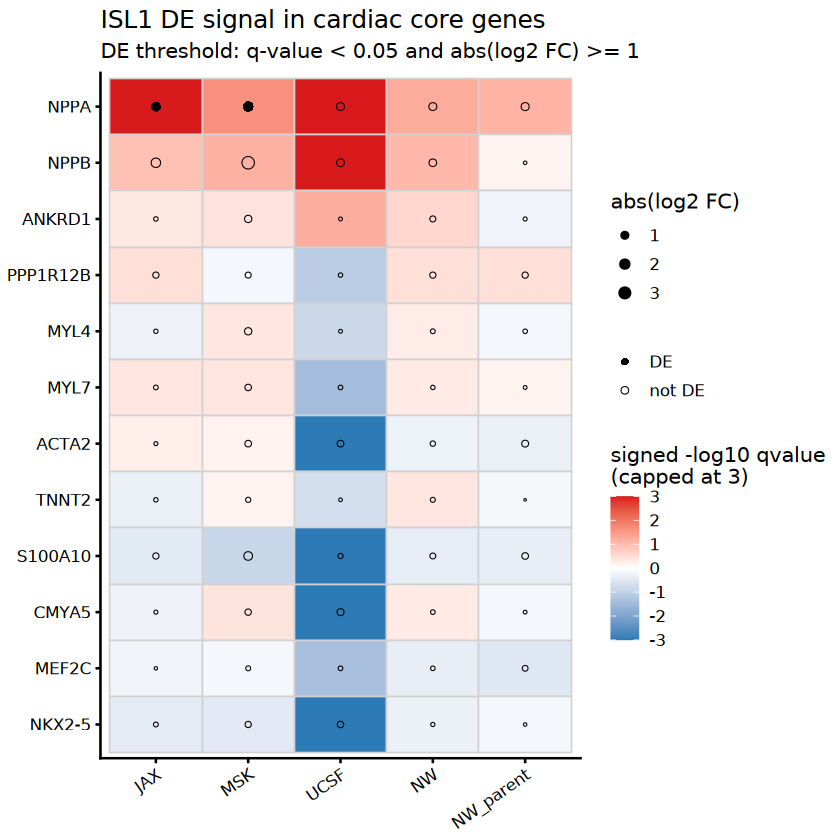

In [8]:
plot_df <- core_gene_presence %>%
  mutate(
    canonical_gene = factor(canonical_gene, levels = rev(core_gene_lookup$canonical_gene)),
    cohort = factor(cohort, levels = cohort_order, ordered = TRUE),
    is_DE_label = if_else(is_DE, "DE", "not DE")
  )

core_gene_plot <- ggplot(plot_df, aes(x = cohort, y = canonical_gene)) +
  geom_tile(aes(fill = signed_neg_log10_qvalue), color = "grey82", linewidth = 0.35) +
  geom_point(aes(size = abs(logFC), shape = is_DE_label), color = "black", stroke = 0.35, na.rm = TRUE) +
  scale_fill_gradient2(
    low = "#2C7BB6",
    mid = "white",
    high = "#D7191C",
    midpoint = 0,
    limits = c(-3, 3),
    oob = scales::squish,
    na.value = "grey92",
    name = "signed -log10 qvalue
(capped at 3)"
  ) +
  scale_size_continuous(range = c(0.2, 3), name = "abs(log2 FC)") +
  scale_shape_manual(values = c("not DE" = 1, "DE" = 16), name = NULL) +
  labs(
    title = "ISL1 DE signal in cardiac core genes",
    subtitle = paste0("DE threshold: ", de_threshold_label),
    x = NULL,
    y = NULL
  ) +
  theme(
    axis.text.x = element_text(angle = 35, hjust = 1),
    panel.grid = element_blank(),
    legend.position = "right"
  )

plot_output_file <- file.path(output_dir, "ISL1_core_gene_DE_dotplot.png")
ggsave(plot_output_file, core_gene_plot, width = 7, height = 3.6, dpi = 300)

core_gene_plot
plot_output_file


## Significant core-gene hits only

In [9]:
core_gene_presence %>%
  filter(is_DE) %>%
  arrange(canonical_gene, cohort) %>%
  select(canonical_gene, cohort, logFC, qvalue, DE_direction, rank_by_qvalue, source_file)


canonical_gene,cohort,logFC,qvalue,DE_direction,rank_by_qvalue,source_file
<chr>,<ord>,<dbl>,<dbl>,<chr>,<int>,<chr>
NPPA,JAX,1.880465,0.001011703,up,10,ISL1_DE_JAX.csv
NPPA,MSK,2.241444,0.022827807,up,25,ISL1_DE_MSK.csv


## Core-gene expression across DE comparison samples

Raw counts are TMM-normalized to log2 CPM. Each panel includes only the samples used for that cohort's DE comparison; samples reused by multiple comparisons appear in each applicable cohort panel.

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_expression_boxplots.png"

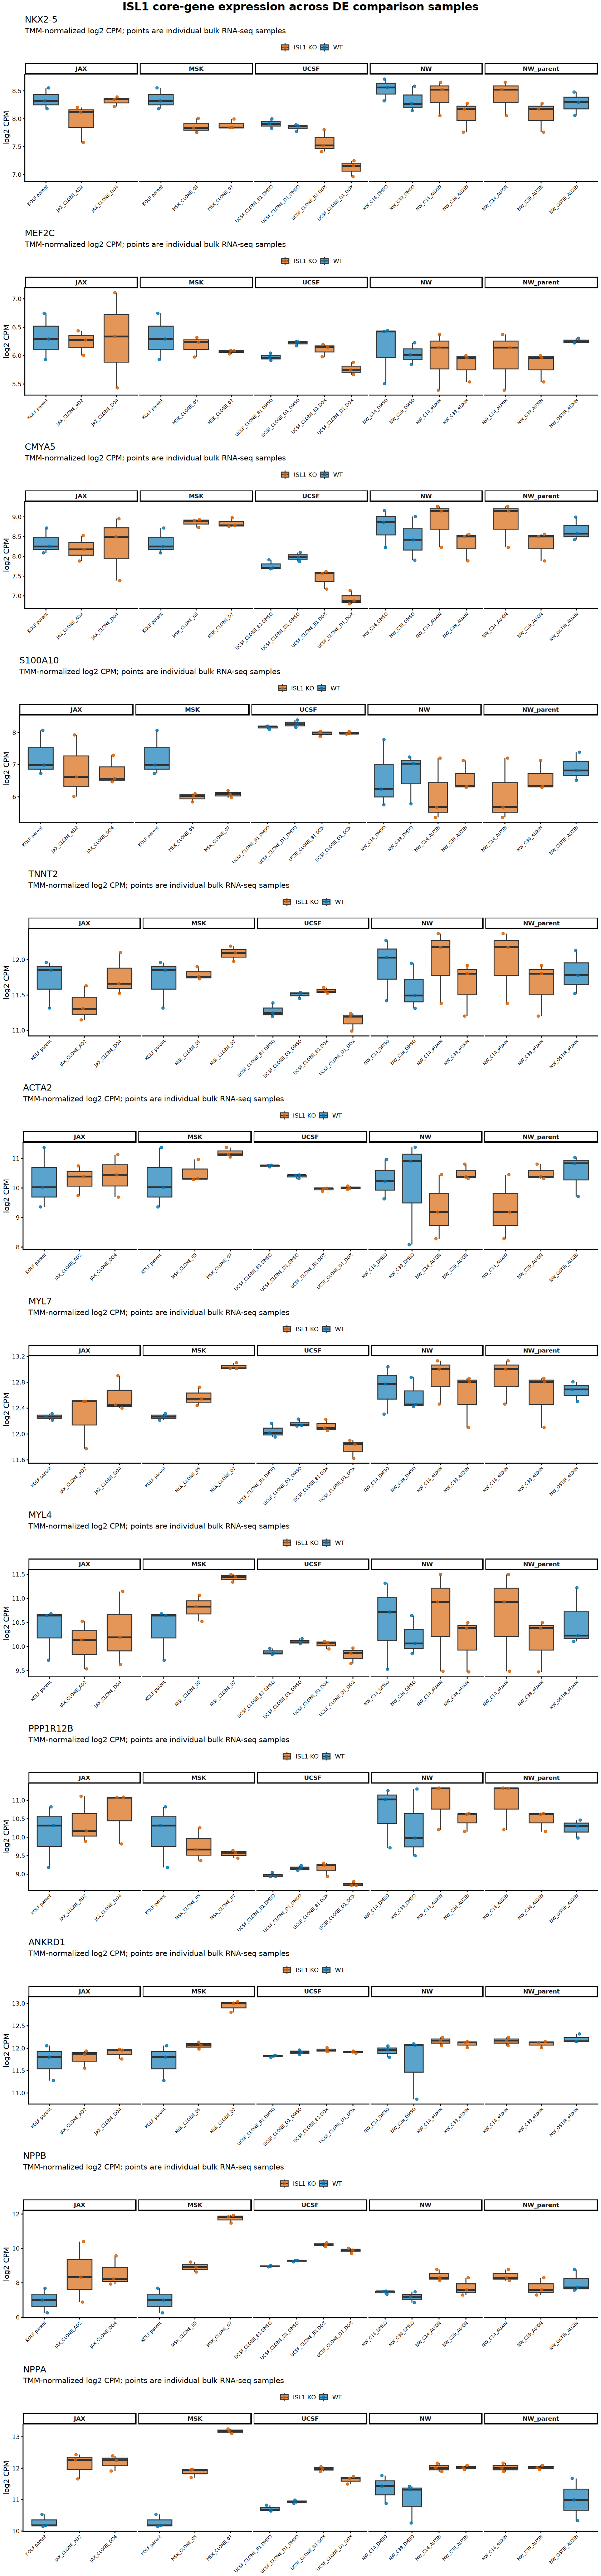

In [10]:
expression_data_dir <- file.path(
  "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment",
  "DRACC-processed/NW_exchange_experiment_DRACC_processed_March2026/Tables"
)
expression_meta_file <- file.path(personal_path, "NW_meta_data.tsv")
expression_counts_file <- file.path(expression_data_dir, "genesCounts.csv")
expression_gene_annotation_file <- "/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv"

# Load the same bulk count matrix and metadata used for the ISL1 DE analyses.
expression_meta <- data.table::fread(expression_meta_file, data.table = FALSE)
expression_counts <- data.table::fread(expression_counts_file, data.table = FALSE)
colnames(expression_counts) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(expression_counts))

stopifnot(
  setequal(expression_meta$Name, colnames(expression_counts)[-1]),
  !anyDuplicated(expression_meta$Name),
  !anyDuplicated(colnames(expression_counts)[-1])
)

expression_meta <- expression_meta[match(colnames(expression_counts)[-1], expression_meta$Name), ]
expression_counts_matrix <- data.matrix(expression_counts[, -1])
rownames(expression_counts_matrix) <- expression_counts$Name

# Map Ensembl IDs to HGNC symbols and aggregate duplicate symbols before normalization.
expression_gene_annotation <- data.table::fread(expression_gene_annotation_file, data.table = FALSE)
expression_gene_symbols <- expression_gene_annotation$hgnc_symbol[
  match(rownames(expression_counts_matrix), expression_gene_annotation$ensembl_gene_id)
]
valid_symbols <- !is.na(expression_gene_symbols) & expression_gene_symbols != ""
expression_counts_by_symbol <- rowsum(
  expression_counts_matrix[valid_symbols, , drop = FALSE],
  group = expression_gene_symbols[valid_symbols],
  reorder = FALSE
)

expression_dge <- edgeR::DGEList(counts = expression_counts_by_symbol)
expression_dge <- edgeR::calcNormFactors(expression_dge, method = "TMM")
expression_log_cpm <- edgeR::cpm(expression_dge, log = TRUE, prior.count = 1)

# These are the exact condition sets used in the five exported DE comparisons.
comparison_conditions <- list(
  JAX = c("JAX_CLONE_AD2", "JAX_CLONE_DO4", "KOLF_PARENT_NA"),
  MSK = c("MSK_CLONE_05", "MSK_CLONE_07", "KOLF_PARENT_NA"),
  UCSF = c("UCSF_CLONE_D1_DOX", "UCSF_CLONE_D1_DMSO", "UCSF_CLONE_B1 DOX", "UCSF_CLONE_B1 DMSO"),
  NW = c("NW_C14_AUXIN", "NW_C39_AUXIN", "NW_C39_DMSO", "NW_C14_DMSO"),
  NW_parent = c("NW_C14_AUXIN", "NW_C39_AUXIN", "NW_OSTIR_AUXIN")
)

comparison_samples <- purrr::imap_dfr(comparison_conditions, function(conditions, cohort_name) {
  expression_meta %>%
    filter(Dcondition %in% conditions) %>%
    transmute(
      cohort = cohort_name,
      SampleName = Name,
      Dcondition,
      ko_gene = as.character(ko_gene)
    )
}) %>%
  distinct()

# Use a cohort-specific x key so each facet can keep its WT conditions on the left.
condition_order <- comparison_samples %>%
  mutate(
    cohort = factor(cohort, levels = cohort_order, ordered = TRUE),
    condition_label = recode(Dcondition, "KOLF_PARENT_NA" = "KOLF parent"),
    ko_status = factor(
      if_else(toupper(ko_gene) == "WT", "WT", "ISL1 KO"),
      levels = c("WT", "ISL1 KO"),
      ordered = TRUE
    )
  ) %>%
  distinct(cohort, Dcondition, .keep_all = TRUE) %>%
  arrange(cohort, ko_status, condition_label) %>%
  transmute(
    condition_key = paste(cohort, Dcondition, sep = "__"),
    condition_label
  )

selected_core_genes <- intersect(core_gene_lookup$canonical_gene, rownames(expression_log_cpm))
missing_core_genes <- setdiff(core_gene_lookup$canonical_gene, selected_core_genes)
if (length(missing_core_genes) > 0) {
  message("Core genes not found in the bulk count matrix: ", paste(missing_core_genes, collapse = ", "))
}
stopifnot(length(selected_core_genes) > 0)

core_expression_long <- as.data.frame(expression_log_cpm[selected_core_genes, , drop = FALSE]) %>%
  tibble::rownames_to_column("canonical_gene") %>%
  pivot_longer(
    cols = -canonical_gene,
    names_to = "SampleName",
    values_to = "log2_CPM"
  ) %>%
  inner_join(comparison_samples, by = "SampleName", relationship = "many-to-many") %>%
  mutate(
    cohort = factor(cohort, levels = cohort_order, ordered = TRUE),
    canonical_gene = factor(canonical_gene, levels = rev(core_gene_lookup$canonical_gene)),
    condition_key = factor(
      paste(cohort, Dcondition, sep = "__"),
      levels = condition_order$condition_key,
      labels = condition_order$condition_label,
      ordered = TRUE
    ),
    ko_status = if_else(toupper(ko_gene) == "WT", "WT", "ISL1 KO")
  )

# Build one plot per gene, then stack those plots into a single figure.
core_gene_expression_plots <- core_expression_long %>%
  split(.$canonical_gene) %>%
  purrr::imap(function(gene_data, gene) {
    ggplot(
      gene_data,
      aes(x = condition_key, y = log2_CPM, fill = ko_status)
    ) +
      geom_boxplot(outlier.shape = NA, width = 0.7, alpha = 0.65) +
      geom_point(
        aes(color = ko_status),
        position = position_jitter(width = 0.12, height = 0),
        size = 1.5,
        alpha = 0.8
      ) +
      facet_wrap(~ cohort, scales = "free_x", nrow = 1) +
      scale_fill_manual(values = c("ISL1 KO" = "#D55E00", "WT" = "#0072B2"), name = NULL) +
      scale_color_manual(values = c("ISL1 KO" = "#D55E00", "WT" = "#0072B2"), name = NULL) +
      labs(
        title = gene,
        subtitle = "TMM-normalized log2 CPM; points are individual bulk RNA-seq samples",
        x = NULL,
        y = "log2 CPM"
      ) +
      theme(
        axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        strip.text = element_text(face = "bold"),
        panel.spacing = grid::unit(0.25, "lines"),
        legend.position = "top"
      )
  })

core_gene_expression_figure <- do.call(
  gridExtra::arrangeGrob,
  c(
    unname(core_gene_expression_plots),
    list(
      ncol = 1,
      top = grid::textGrob(
        "ISL1 core-gene expression across DE comparison samples",
        gp = grid::gpar(fontface = "bold", fontsize = 18)
      )
    )
  )
)

expression_plot_output_file <- file.path(output_dir, "ISL1_core_gene_expression_boxplots.png")
ggsave(
  expression_plot_output_file,
  core_gene_expression_figure,
  width = 14,
  height = max(6, 4 * length(core_gene_expression_plots)),
  dpi = 300
)

# Render the stacked figure inside the notebook, too.
previous_repr_options <- options(
  repr.plot.width = 14,
  repr.plot.height = max(10, 5 * length(core_gene_expression_plots))
)
grid::grid.newpage()
grid::grid.draw(core_gene_expression_figure)
options(previous_repr_options)

expression_plot_output_file